# Score-Based Generative Modeling


### Goals
This is a hitchhiker's guide to score-based generative models, a family of approaches based on [estimating gradients of the data distribution](https://arxiv.org/abs/1907.05600).

# Dataloading

In [20]:
import sys
import os
os.environ['HDF5_USE_FILE_LOCKING']='FALSE'
import matplotlib.pyplot as plt
import torch
import itertools
import geopandas as gpd
from geopandas import GeoSeries
import cartopy.feature as cfeature
import matplotlib

CODE_DIR   = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/Code'
CACHE_DIR  = '/dmidata/projects/asip-cms/ninna_msc/zarr_cache'
FUSION_CKPT = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/training/fusionnetaspp/best_model_1.pth'
DIFF_CKPT  = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/diffusion/ckpt_diff_fusionnetaspp.pth'  # save diffusion ckpt here

sys.path.append(CODE_DIR)
from lib.model.FusionNetASPP import FusionNetASPP
from lib.dataset.dataloader import AMSR2Dataset, collate_pad_to_max
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

### Load model FusionNetASPP (frozen condition encoder)
fusion_ckpt = torch.load(FUSION_CKPT, map_location=device, weights_only=True)
fusion_model = FusionNetASPP(in_channels=fusion_ckpt['in_channels'], features=fusion_ckpt['features']).to(device)
fusion_model.load_state_dict(fusion_ckpt['model_state_dict'])
fusion_model.eval()
print(f'FusionNetASPP loaded — epoch={fusion_ckpt["epoch"]}  val_rmse={fusion_ckpt["val_rmse"]:.2f}%')

### Load datasets and dataloaders
BATCH_SIZE = 32
NUM_WORKERS = 4

train_dataset = AMSR2Dataset(CACHE_DIR, split='train')
val_dataset   = AMSR2Dataset(CACHE_DIR, split='val')

data_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=False,
    persistent_workers=True, collate_fn=collate_pad_to_max,
)
val_dataloader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=False,
    persistent_workers=True, collate_fn=collate_pad_to_max,
)

Using device: cuda
FusionNetASPP loaded — epoch=150  val_rmse=6.36%


# UNet-based score parametrization

In [12]:
#@title Defining a time-dependent score-based model (double click to expand or collapse)

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class GaussianFourierProjection(nn.Module):
  """Gaussian random features for encoding time steps."""  
  def __init__(self, embed_dim, scale=30.):
    super().__init__()
    # Randomly sample weights during initialization. These weights are fixed 
    # during optimization and are not trainable.
    self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)

  def forward(self, x):
    x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
    ret = torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)
    return ret

class Dense(nn.Module):
    """A fully connected layer that reshapes outputs to feature maps.
  Allow time repr to input additively from the side of a convolution layer.
  """
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.dense = nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.dense(x)[..., None, None] # add one dimension here with one more None

def center_crop(tensor, target_tensor):
    # Crop tensor to match target_tensor shape
    _, _, d, h, w = target_tensor.shape
    td, th, tw = tensor.shape[2:]
    d1 = (td - d) // 2
    h1 = (th - h) // 2
    w1 = (tw - w) // 2
    return tensor[:, :, d1:d1+d, h1:h1+h, w1:w1+w]
    
class ScoreNet(nn.Module):
    """A 2D score-based model built upon U-Net architecture for sinlge-image SR."""

    def __init__(self, marginal_prob_std, channels=[32, 64, 128, 256], embed_dim=256):
        super().__init__()
        self.act = nn.SiLU()  # lambda x: x * torch.sigmoid(x)
        # Gaussian random feature embedding layer for time
        self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
                                   nn.Linear(embed_dim, embed_dim))
        self.marginal_prob_std = marginal_prob_std

        # Encoder
        self.conv1 = nn.Conv2d(2, channels[0], kernel_size=3, padding=1, bias=False)
        self.conv2 = nn.Conv2d(channels[0], channels[1], 3, stride=2, padding=1, bias=False)
        self.conv3 = nn.Conv2d(channels[1], channels[2], 3, stride=2, padding=1, bias=False)
        self.conv4 = nn.Conv2d(channels[2], channels[3], 3, stride=2, padding=1, bias=False)
        
        # Dense time embedding layers for the encoder
        self.dense1 = Dense(embed_dim, channels[0]) 
        self.dense2 = Dense(embed_dim, channels[1])
        self.dense3 = Dense(embed_dim, channels[2])
        self.dense4 = Dense(embed_dim, channels[3])

        # Group norms for the encoder
        self.gnorm1 = nn.GroupNorm(4, channels[0]) 
        self.gnorm2 = nn.GroupNorm(32, channels[1])
        self.gnorm3 = nn.GroupNorm(32, channels[2])
        self.gnorm4 = nn.GroupNorm(32, channels[3])

        # Decoder
        self.tconv4 = nn.ConvTranspose2d(channels[3], channels[2], 3, stride=2, padding=1, output_padding=1, bias=False)
        self.tconv3 = nn.ConvTranspose2d(channels[2]*2, channels[1], 3, stride=2, padding=1, output_padding=1, bias=False)
        self.tconv2 = nn.ConvTranspose2d(channels[1]*2, channels[0], 3, stride=2, padding=1, output_padding=1, bias=False)
        self.tconv1 = nn.Conv2d(channels[0]*2, 1, 3, padding=1) # final output — regular conv

        # Dense layers for the decoder
        self.dense5 = Dense(embed_dim, channels[2])
        self.dense6 = Dense(embed_dim, channels[1])
        self.dense7 = Dense(embed_dim, channels[0])

        # Group norms for the decoder
        self.tgnorm4 = nn.GroupNorm(32, channels[2])
        self.tgnorm3 = nn.GroupNorm(32, channels[1])
        self.tgnorm2 = nn.GroupNorm(4, channels[0])


    def forward(self, x, t, y):
        # x: (B, 1, H, W) perturbed SIC
        # y: (B, 1, H, W) FusionNetASPP condition
        x = torch.cat([x, y], dim=1)  # (B, 2, H, W)   

        embed = self.act(self.embed(t))  # (B, embed_dim)

        # Encoder
        h1 = self.act(self.gnorm1(self.conv1(x)  + self.dense1(embed)))   # (B, C0, H,   W)
        h2 = self.act(self.gnorm2(self.conv2(h1) + self.dense2(embed)))   # (B, C1, H/2, W/2)
        h3 = self.act(self.gnorm3(self.conv3(h2) + self.dense3(embed)))   # (B, C2, H/4, W/4)
        h4 = self.act(self.gnorm4(self.conv4(h3) + self.dense4(embed)))   # (B, C3, H/8, W/8)

        # # Decoder with skip connections
        # h  = self.act(self.tgnorm4(self.tconv4(h4) + self.dense5(embed)))  # (B, C2, H/4, W/4)
        # h  = self.act(self.tgnorm3(self.tconv3(torch.cat([h, h3], dim=1)) + self.dense6(embed)))  # (B, C1, H/2, W/2)
        # h  = self.act(self.tgnorm2(self.tconv2(torch.cat([h, h2], dim=1)) + self.dense7(embed)))  # (B, C0, H,   W)
        # out = self.tconv1(torch.cat([h, h1], dim=1))  # (B, 1, H, W)

        # Decoder — snap decoder output to skip connection size before concat
        h  = self.act(self.tgnorm4(self.tconv4(h4) + self.dense5(embed)))
        h  = F.interpolate(h,  size=h3.shape[2:], mode='nearest')
        h  = self.act(self.tgnorm3(self.tconv3(torch.cat([h, h3], dim=1)) + self.dense6(embed)))
        h  = F.interpolate(h,  size=h2.shape[2:], mode='nearest')
        h  = self.act(self.tgnorm2(self.tconv2(torch.cat([h, h2], dim=1)) + self.dense7(embed)))
        h  = F.interpolate(h,  size=h1.shape[2:], mode='nearest')
        out = self.tconv1(torch.cat([h, h1], dim=1))
        
        # Normalise by marginal probability std
        out = out / self.marginal_prob_std(t)[:, None, None, None]

        return out

## Training with Weighted Sum of Denoising Score Matching Objectives

Now let's get our hands dirty on training. First of all, we need to specify an SDE that perturbs the data distribution $p_0$ to a prior distribution $p_T$. We choose the following SDE
\begin{align*}
d \mathbf{x} = \sigma^t d\mathbf{w}, \quad t\in[0,1]
\end{align*}
In this case,
\begin{align*}
p_{0t}(\mathbf{x}(t) \mid \mathbf{x}(0)) = \mathcal{N}\bigg(\mathbf{x}(t); \mathbf{x}(0), \frac{1}{2\log \sigma}(\sigma^{2t} - 1) \mathbf{I}\bigg)
\end{align*}
and we can choose the weighting function $\lambda(t) = \frac{1}{2 \log \sigma}(\sigma^{2t} - 1)$.

When $\sigma$ is large, the prior distribution, $p_{t=1}$ is
\begin{align*}
\int p_0(\mathbf{y})\mathcal{N}\bigg(\mathbf{x}; \mathbf{y}, \frac{1}{2 \log \sigma}(\sigma^2 - 1)\mathbf{I}\bigg) d \mathbf{y} \approx \mathbf{N}\bigg(\mathbf{x}; \mathbf{0}, \frac{1}{2 \log \sigma}(\sigma^2 - 1)\mathbf{I}\bigg),
\end{align*}
which is approximately independent of the data distribution and is easy to sample from.

Intuitively, this SDE captures a continuum of Gaussian perturbations with variance function $\frac{1}{2 \log \sigma}(\sigma^{2t} - 1)$. This continuum of perturbations allows us to gradually transfer samples from a data distribution $p_0$ to a simple Gaussian distribution $p_1$.

In [13]:
#@title Set up the SDE

import functools
device = 'cuda'
#device = 'cpu' #@param ['cuda', 'cpu'] {'type':'string'}

def marginal_prob_std(t, sigma):
  """Compute the mean and standard deviation of $p_{0t}(x(t) | x(0))$.

  Args:
    t: A vector of time steps.
    sigma: The sigma in our SDE.

  Returns:
    The standard deviation.
  """
  t = torch.tensor(t, device=device)
  return torch.sqrt((sigma**(2 * t) - 1.) / 2. / np.log(sigma))

def diffusion_coeff(t, sigma):
  """Compute the diffusion coefficient of our SDE.

  Args:
    t: A vector of time steps.
    sigma: The sigma in our SDE.

  Returns:
    The vector of diffusion coefficients.
  """
  return torch.tensor(sigma**t, device=device)

sigma =  25.0#@param {'type':'number'}
#sigma = 5.0
marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=sigma)
diffusion_coeff_fn = functools.partial(diffusion_coeff, sigma=sigma)

In [14]:
#@title Define the loss function (double click to expand or collapse)

def loss_fn(model, x, y, marginal_prob_std, eps=1e-5):
  """The loss function for training score-based generative models.

  Args:
    model: A PyTorch model instance that represents a
      time-dependent score-based model.
    x: A mini-batch of training data.
    marginal_prob_std: A function that gives the standard deviation of
      the perturbation kernel.
    eps: A tolerance value for numerical stability.
  """
  random_t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps
  z = torch.randn_like(x).to(device)
  std = marginal_prob_std(random_t)
  perturbed_x = x + z * std[:, None, None, None]
  score = model(perturbed_x, y, random_t)
  loss = torch.mean(torch.sum((score * std[:, None, None, None] + z)**2, dim=(1,2,3)))
  return loss

def masked_loss_fn(model, x,  y, marginal_prob_std, eps=1e-5):
  """The loss function for training score-based generative models.

  Args:
    model: A PyTorch model instance that represents a
      time-dependent score-based model.
    x: A mini-batch of training data.
    marginal_prob_std: A function that gives the standard deviation of
      the perturbation kernel.
    eps: A tolerance value for numerical stability.
  """

  mask = ~torch.isnan(x)  # mask is True where x is not NaN
  x = torch.nan_to_num(x)  
  y = torch.nan_to_num(y)  
  
  random_t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps
  z = torch.randn_like(x)
  std = marginal_prob_std(random_t)
  perturbed_x = x + z * std[:, None, None, None] # add one dimension here
  score = model(perturbed_x, t=random_t, y=y)#, mask=mask_obs)
  
  # Step 2: Compute the loss as usual
  loss = (score * std[:, None, None, None] + z) ** 2 # add one dimension here
  
  # Step 3: Apply the mask
  loss = loss * mask.float()  # Only consider non-NaN pixels
  
  # Step 4: Compute the mean loss over valid pixels
  loss = torch.sum(loss, dim=(1, 2, 3))  # Sum over spatial dimensions
  valid_pixel_count = torch.sum(mask, dim=(1, 2, 3))  # Count valid pixels
  loss = loss / valid_pixel_count  # Normalize loss by valid pixel count
  loss = torch.mean(loss)  # Average over the batch
  return loss

## Sampling with Numerical SDE Solvers
Recall that for any SDE of the form
\begin{align*}
d \mathbf{x} = \mathbf{f}(\mathbf{x}, t) dt + g(t) d\mathbf{w},
\end{align*}
the reverse-time SDE is given by
\begin{align*}
d \mathbf{x} = [\mathbf{f}(\mathbf{x}, t) - g(t)^2 \nabla_\mathbf{x} \log p_t(\mathbf{x})] dt + g(t) d \bar{\mathbf{w}}.
\end{align*}
Since we have chosen the forward SDE to be
\begin{align*}
d \mathbf{x} = \sigma^t d\mathbf{w}, \quad t\in[0,1]
\end{align*}
The reverse-time SDE is given by
\begin{align*}
d\mathbf{x} = -\sigma^{2t} \nabla_\mathbf{x} \log p_t(\mathbf{x}) dt + \sigma^t d \bar{\mathbf{w}}.
\end{align*}
To sample from our time-dependent score-based model $s_\theta(\mathbf{x}, t)$, we first draw a sample from the prior distribution $p_1 \approx \mathbf{N}\bigg(\mathbf{x}; \mathbf{0}, \frac{1}{2}(\sigma^{2} - 1) \mathbf{I}\bigg)$, and then solve the reverse-time SDE with numerical methods.

In particular, using our time-dependent score-based model, the reverse-time SDE can be approximated by
\begin{align*}
d\mathbf{x} = -\sigma^{2t} s_\theta(\mathbf{x}, t) dt + \sigma^t d \bar{\mathbf{w}}
\end{align*}

Next, one can use numerical methods to solve for the reverse-time SDE, such as the [Euler-Maruyama](https://en.wikipedia.org/wiki/Euler%E2%80%93Maruyama_method) approach. It is based on a simple discretization to the SDE, replacing $dt$ with $\Delta t$ and $d \mathbf{w}$ with $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, g^2(t) \Delta t \mathbf{I})$. When applied to our reverse-time SDE, we can obtain the following iteration rule
\begin{align}
\mathbf{x}_{t-\Delta t} = \mathbf{x}_t + \sigma^{2t} s_\theta(\mathbf{x}_t, t)\Delta t + \sigma^t\sqrt{\Delta t} \mathbf{z}_t,
\end{align}
where $\mathbf{z}_t \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$.

In [29]:
#@title Define the Euler-Maruyama sampler (double click to expand or collapse)
from tqdm.autonotebook import tqdm

## The number of sampling steps.
num_steps =  500#@param {'type':'integer'}

def Euler_Maruyama_sampler(score_model,
                           marginal_prob_std,
                           diffusion_coeff,
                           y,
                           batch_size=64,
                           num_steps=num_steps,
                           device='cuda',
                           eps=1e-3):
  """Generate samples from score-based models with the Euler-Maruyama solver.

  Args:
    score_model: A PyTorch model that represents the time-dependent score-based model.
    marginal_prob_std: A function that gives the standard deviation of
      the perturbation kernel.
    diffusion_coeff: A function that gives the diffusion coefficient of the SDE.
    batch_size: The number of samplers to generate by calling this function once.
    num_steps: The number of sampling steps.
      Equivalent to the number of discretized time steps.
    device: 'cuda' for running on GPUs, and 'cpu' for running on CPUs.
    eps: The smallest time step for numerical stability.

  Returns:
    Samples.
  """
  t = torch.ones(batch_size, device=device)
  init_x = torch.randn(batch_size, 1, y.shape[-2], y.shape[-1], device=device) \
          * marginal_prob_std(t)[:, None, None, None]
  time_steps = torch.linspace(1., eps, num_steps, device=device)
  tqdm_time_steps = tqdm(time_steps)    
  step_size = time_steps[0] - time_steps[1]
  x = init_x
  mask_obs = ~torch.isnan(y)
  y = y.nan_to_num()
  with torch.no_grad():
    for time_step in tqdm_time_steps:
      batch_time_step = torch.ones(batch_size, device=device) * time_step
      g = diffusion_coeff(batch_time_step)
      mean_x = x + (g**2)[:, None, None, None] * score_model(x, batch_time_step, y) * step_size
      x = mean_x + torch.sqrt(step_size) * g[:, None, None, None] * torch.randn_like(x)
  # Do not include any noise in the last sampling step.
  return mean_x

## Sampling with Predictor-Corrector Methods

Aside from generic numerical SDE solvers, we can leverage special properties of our reverse-time SDE for better solutions. Since we have an estimate of the score of $p_t(\mathbf{x}(t))$ via the score-based model, i.e., $s_\theta(\mathbf{x}, t) \approx \nabla_{\mathbf{x}(t)} \log p_t(\mathbf{x}(t))$, we can leverage score-based MCMC approaches, such as Langevin MCMC, to correct the solution obtained by numerical SDE solvers.

Score-based MCMC approaches can produce samples from a distribution $p(\mathbf{x})$ once its score $\nabla_\mathbf{x} \log p(\mathbf{x})$ is known. For example, Langevin MCMC operates by running the following iteration rule for $i=1,2,\cdots, N$:
\begin{align*}
\mathbf{x}_{i+1} = \mathbf{x}_{i} + \epsilon \nabla_\mathbf{x} \log p(\mathbf{x}_i) + \sqrt{2\epsilon} \mathbf{z}_i,
\end{align*}
where $\mathbf{z}_i \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$, $\epsilon > 0$ is the step size, and $\mathbf{x}_1$ is initialized from any prior distribution $\pi(\mathbf{x}_1)$. When $N\to\infty$ and $\epsilon \to 0$, the final value $\mathbf{x}_{N+1}$ becomes a sample from $p(\mathbf{x})$ under some regularity conditions. Therefore, given $s_\theta(\mathbf{x}, t) \approx \nabla_\mathbf{x} \log p_t(\mathbf{x})$, we can get an approximate sample from $p_t(\mathbf{x})$ by running several steps of Langevin MCMC, replacing $\nabla_\mathbf{x} \log p_t(\mathbf{x})$ with $s_\theta(\mathbf{x}, t)$ in the iteration rule.

Predictor-Corrector samplers combine both numerical solvers for the reverse-time SDE and the Langevin MCMC approach. In particular, we first apply one step of numerical SDE solver to obtain $\mathbf{x}_{t-\Delta t}$ from $\mathbf{x}_t$, which is called the "predictor" step. Next, we apply several steps of Langevin MCMC to refine $\mathbf{x}_t$, such that $\mathbf{x}_t$ becomes a more accurate sample from $p_{t-\Delta t}(\mathbf{x})$. This is the "corrector" step as the MCMC helps reduce the error of the numerical SDE solver.

In [21]:
#@title Define the Predictor-Corrector sampler (double click to expand or collapse)

signal_to_noise_ratio = 0.16 #@param {'type':'number'}

## The number of sampling steps.
num_steps =  500#@param {'type':'integer'}
def pc_sampler(score_model,
               marginal_prob_std,
               diffusion_coeff,
               batch_size=64,
               num_steps=num_steps,
               snr=signal_to_noise_ratio,
               device='cuda',
               eps=1e-3,
               cond=False):
  """Generate samples from score-based models with Predictor-Corrector method.

  Args:
    score_model: A PyTorch model that represents the time-dependent score-based model.
    marginal_prob_std: A function that gives the standard deviation
      of the perturbation kernel.
    diffusion_coeff: A function that gives the diffusion coefficient
      of the SDE.
    batch_size: The number of samplers to generate by calling this function once.
    num_steps: The number of sampling steps.
      Equivalent to the number of discretized time steps.
    device: 'cuda' for running on GPUs, and 'cpu' for running on CPUs.
    eps: The smallest time step for numerical stability.

  Returns:
    Samples.
  """
  t = torch.ones(batch_size, device=device)
  init_x = torch.randn(batch_size, 15, 240, 240, device=device) * marginal_prob_std(t)[:, None, None, None]
  time_steps = np.linspace(1., eps, num_steps)
  tqdm_time_steps = tqdm(time_steps)  
  step_size = time_steps[0] - time_steps[1]
  x = init_x
  with torch.no_grad():
    for time_step in tqdm_time_steps:
      batch_time_step = torch.ones(batch_size, device=device) * time_step
      # Corrector step (Langevin MCMC)
      grad = score_model(x, batch_time_step)   
      grad_norm = torch.norm(grad.reshape(grad.shape[0], -1), dim=-1).mean()
      noise_norm = np.sqrt(np.prod(x.shape[1:]))
      langevin_step_size = 2 * (snr * noise_norm / grad_norm)**2
      x = x + langevin_step_size * grad + torch.sqrt(2 * langevin_step_size) * torch.randn_like(x)

      # Predictor step (Euler-Maruyama)
      g = diffusion_coeff(batch_time_step)
      if cond:
        x_mean = x + (g**2)[:, None, None, None] * (score_model(x, batch_time_step) + grado) * step_size
      else:
        x_mean = x + (g**2)[:, None, None, None] * (score_model(x, batch_time_step)) * step_size  
      x = x_mean + torch.sqrt(g**2 * step_size)[:, None, None, None] * torch.randn_like(x)

    # The last step does not include any noise
    return x_mean

test = True
if test:
  # test
  ckpt = torch.load(DIFF_CKPT, map_location=device)
  score_model.load_state_dict(ckpt)
  x_estim = pc_sampler(score_model,
                           marginal_prob_std_fn,
                           diffusion_coeff_fn,
                           batch_size=4,
                           num_steps=num_steps,
                           snr=signal_to_noise_ratio,
                           device=device,
                           eps=1e-3) 

  xr.Dataset(data_vars={'ssh':(('time','lat','lon'),x_estim.detach().cpu()[0])},
           coords={'time':np.arange(15),
                   'lon':np.arange(-66, -54, 0.05),
                   'lat':np.arange(32, 44, 0.05)}).ssh.plot(col='time',col_wrap=5)
  plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]


TypeError: ScoreNet.forward() missing 1 required positional argument: 'y'

## Sampling with Numerical ODE Solvers

For any SDE of the form
\begin{align*}
d \mathbf{x} = \mathbf{f}(\mathbf{x}, t) d t + g(t) d \mathbf{w},
\end{align*}
there exists an associated ordinary differential equation (ODE)
\begin{align*}
d \mathbf{x} = \bigg[\mathbf{f}(\mathbf{x}, t) - \frac{1}{2}g(t)^2 \nabla_\mathbf{x} \log p_t(\mathbf{x})\bigg] dt,
\end{align*}
such that their trajectories have the same mariginal probability density $p_t(\mathbf{x})$. Therefore, by solving this ODE in the reverse time direction, we can sample from the same distribution as solving the reverse-time SDE.
We call this ODE the *probability flow ODE*.

Below is a schematic figure showing how trajectories from this probability flow ODE differ from SDE trajectories, while still sampling from the same distribution.
![SDE and ODE](https://drive.google.com/uc?id=1CGFbtY2mCjlIY8pjvoGevfa_32d4b1dj)

Therefore, we can start from a sample from $p_T$, integrate the ODE in the reverse time direction, and then get a sample from $p_0$. In particular, for the SDE in our running example, we can integrate the following ODE from $t=T$ to $0$ for sample generation
\begin{align*}
d\mathbf{x} =  -\frac{1}{2}\sigma^{2t} s_\theta(\mathbf{x}, t) dt.
\end{align*}
This can be done using many black-box ODE solvers provided by packages such as `scipy`.

In [17]:
#@title Define the ODE sampler (double click to expand or collapse)

from scipy import integrate

## The error tolerance for the black-box ODE solver
error_tolerance = 1e-5 #@param {'type': 'number'}
def ode_sampler(score_model,
                marginal_prob_std,
                diffusion_coeff,
                y,
                batch_size=64,
                atol=error_tolerance,
                rtol=error_tolerance,
                device='cuda',
                z=None,
                eps=1e-3):
  """Generate samples from score-based models with black-box ODE solvers.

  Args:
    score_model: A PyTorch model that represents the time-dependent score-based model.
    marginal_prob_std: A function that returns the standard deviation
      of the perturbation kernel.
    diffusion_coeff: A function that returns the diffusion coefficient of the SDE.
    batch_size: The number of samplers to generate by calling this function once.
    atol: Tolerance of absolute errors.
    rtol: Tolerance of relative errors.
    device: 'cuda' for running on GPUs, and 'cpu' for running on CPUs.
    z: The latent code that governs the final sample. If None, we start from p_1;
      otherwise, we start from the given z.
    eps: The smallest time step for numerical stability.
  """
  t = torch.ones(batch_size, device=device)
  # Create the latent code
  if z is None:
    init_x = torch.randn(batch_size, 9, 120, 120, device=device) \
      * marginal_prob_std(t)[:, None, None, None]
  else:
    init_x = z

  shape = init_x.shape

  def score_eval_wrapper(sample, y, time_steps):
    """A wrapper of the score-based model for use by the ODE solver."""
    sample = torch.tensor(sample, device=device, dtype=torch.float32).reshape(shape)
    y = torch.tensor(y, device=device, dtype=torch.float32).reshape(shape)
    time_steps = torch.tensor(time_steps, device=device, dtype=torch.float32).reshape((sample.shape[0], ))
    with torch.no_grad():
      score = score_model(sample, y, time_steps)
    return score.cpu().numpy().reshape((-1,)).astype(np.float64)

  def ode_func(t, x):
    """The ODE function for use by the ODE solver."""
    time_steps = np.ones((shape[0],)) * t
    g = diffusion_coeff(torch.tensor(t)).cpu().numpy()
    return  -0.5 * (g**2) * score_eval_wrapper(x, y, time_steps)

  # Run the black-box ODE solver.
  res = integrate.solve_ivp(ode_func, (1., eps), init_x.reshape(-1).cpu().numpy(), rtol=rtol, atol=atol, method='RK45')
  print(f"Number of function evaluations: {res.nfev}")
  x = torch.tensor(res.y[:, -1], device=device).reshape(shape)

  return x


# Training

## Understanding this Supervised Loss: how it works intuitively

### First, some basic knowledge about Gaussian distribution


We start by proving: $\nabla_x \log \mathcal{N}(x; \mu, \Sigma) = -\Sigma^{-1} (x - \mu)$
Indeed, the probability density function of a Gaussian (normal) distribution $ \mathcal{N}(x; \mu, \Sigma) $ is given by:
$$
p(x) = \frac{1}{\sqrt{(2\pi)^d |\Sigma|}} \exp\left(-\frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu)\right)
$$
where:
- $\mu$ is the mean vector, $\Sigma$ is the covariance matrix, $d$ is the dimensionality of $x$, $|\Sigma|$ is the determinant of the covariance matrix.

Then the log of the Gaussian probability density is:
$$
\log p(x) = -\frac{d}{2} \log(2\pi) - \frac{1}{2} \log |\Sigma| - \frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu)
$$

Take the gradient of the log probability with respect to $x$:
$$
\nabla_x \log p(x) = \nabla_x \left( -\frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu) \right)
$$
Using matrix calculus, the gradient of the quadratic form is:
$$
\nabla_x \left( (x - \mu)^T \Sigma^{-1} (x - \mu) \right) = 2 \Sigma^{-1} (x - \mu)
$$
Thus, the score function is:
$$
\nabla_x \log p(x) = -\Sigma^{-1} (x - \mu)
$$

### Now, we try to understand the Loss with Transition Probability as a Gaussian

In the context of the score-based generative model, the perturbation process from \( x(0) \) to \( x(t) \) is modeled as a Gaussian:

$
p_{0t}(x(t) \mid x(0)) = \mathcal{N}(x(t); x(0), \text{std}^2(t) I).
$

The Gaussian form of the transition probability:

$$
p_{0t}(x(t) \mid x(0)) = \frac{1}{(2\pi \text{std}^2(t))^{d/2}} \exp\left(-\frac{\|x(t) - x(0)\|^2}{2 \text{std}^2(t)}\right).
$$

Compute the gradient of the log probability with respect to $x(t)$:

$$
\log p_{0t}(x(t) \mid x(0)) = -\frac{d}{2} \log(2\pi \text{std}^2(t)) - \frac{\|x(t) - x(0)\|^2}{2 \text{std}^2(t)}
$$

Taking the gradient with respect to $ x(t) $:

$$
\nabla_{x(t)} \log p_{0t}(x(t) \mid x(0)) = -\nabla_{x(t)} \left(\frac{\|x(t) - x(0)\|^2}{2 \text{std}^2(t)}\right)
$$


Thus, the score function is:

$$
\nabla_{x(t)} \log p_{0t}(x(t) \mid x(0)) = -\frac{x(t) - x(0)}{\text{std}^2(t)}
$$

#### Substitution with Perturbation

Given that $ x(t) = x(0) + z \cdot \text{std}(t) $, substitute into the expression:

$$
x(t) - x(0) = z \cdot \text{std}(t)
$$

Substitute into the score function:

$$
\nabla_{x(t)} \log p_{0t}(x(t) \mid x(0)) = -\frac{z \cdot \text{std}(t)}{\text{std}^2(t)} = -\frac{z}{\text{std}(t)}
$$

This yields:

$$
\nabla_{x(t)} \log p_{0t}(x(t) \mid x(0)) = -\frac{z}{\text{std}(t)}
$$

**And this explains why we have below loss function.**

In [ ]:
#@title Training (double click to expand or collapse)

from IPython.display import clear_output
from torch.optim import Adam
from tqdm.autonotebook import tqdm
import torch.optim.lr_scheduler as lr_scheduler
import warnings
warnings.filterwarnings('ignore')

n_epochs = 100
lr       = 5e-4

score_model = torch.nn.DataParallel(ScoreNet(marginal_prob_std=marginal_prob_std_fn))
score_model = score_model.to(device)

optimizer          = Adam(score_model.parameters(), lr=lr)
scheduler          = lr_scheduler.MultiStepLR(optimizer, milestones=[100, 200, 300, 400, 450, 600, 800, 1000, 1200, 1400], gamma=0.5)
accumulation_steps = 16
start_epoch        = 0

if os.path.exists(DIFF_CKPT):
    ckpt = torch.load(DIFF_CKPT, map_location=device, weights_only=True)
    if isinstance(ckpt, dict) and 'state_dict' in ckpt:
        score_model.load_state_dict(ckpt['state_dict'])
        start_epoch = ckpt['epoch'] + 1
        # Replay scheduler steps to restore correct lr
        for _ in range(start_epoch):
            scheduler.step()
        print(f"Resumed from epoch {ckpt['epoch']}  loss={ckpt['avg_loss']:.5f}  lr={optimizer.param_groups[0]['lr']:.2e}")
    else:
        # Old checkpoint — raw state dict, no epoch info
        score_model.load_state_dict(ckpt)
        print(f"Resumed from checkpoint (no epoch info — starting scheduler from 0)")
else:
    print('No checkpoint found, training from scratch.')

optimizer.zero_grad()

tqdm_epoch = tqdm(range(start_epoch, start_epoch + n_epochs))
for epoch in tqdm_epoch:
    avg_loss  = 0.
    num_items = 0

    for i, (amsr2, sic, mask) in enumerate(data_loader):
        amsr2 = amsr2.to(device)
        sic   = sic.to(device)
        mask  = mask.to(device)

        x           = sic
        target_size = (x.shape[-2], x.shape[-1])

        with torch.no_grad():
            y = fusion_model(amsr2, target_size)

        loss = masked_loss_fn(score_model, x, y, marginal_prob_std_fn)
        if torch.isnan(loss):
            continue

        loss = loss / accumulation_steps
        loss.backward()

        if (i + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        avg_loss  += loss.item() * accumulation_steps * x.shape[0]
        num_items += x.shape[0]

    tqdm_epoch.set_description(f'Epoch {epoch} | avg loss: {avg_loss / max(num_items, 1):.5f}  lr={optimizer.param_groups[0]["lr"]:.2e}')
    torch.save({
        'state_dict': score_model.state_dict(),
        'epoch':      epoch,
        'avg_loss':   avg_loss / max(num_items, 1),
    }, DIFF_CKPT)
    scheduler.step()

Resumed from checkpoint (no epoch info — starting scheduler from 0)


  0%|          | 0/100 [00:00<?, ?it/s]

# Sampling

In [27]:
import cmcrameri as cmc

def truncate_colormap(cmap, minval=0.0, maxval=1.0,n=100):
    new_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
                             'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name,
                              a=minval, b=maxval),
                              cmap(np.linspace(minval, maxval, n)))
    return new_cmap

sic_trunc = truncate_colormap(cmc.cm.oslo, minval=0.2, maxval=1, n=100)

100%|██████████| 500/500 [00:05<00:00, 90.38it/s]


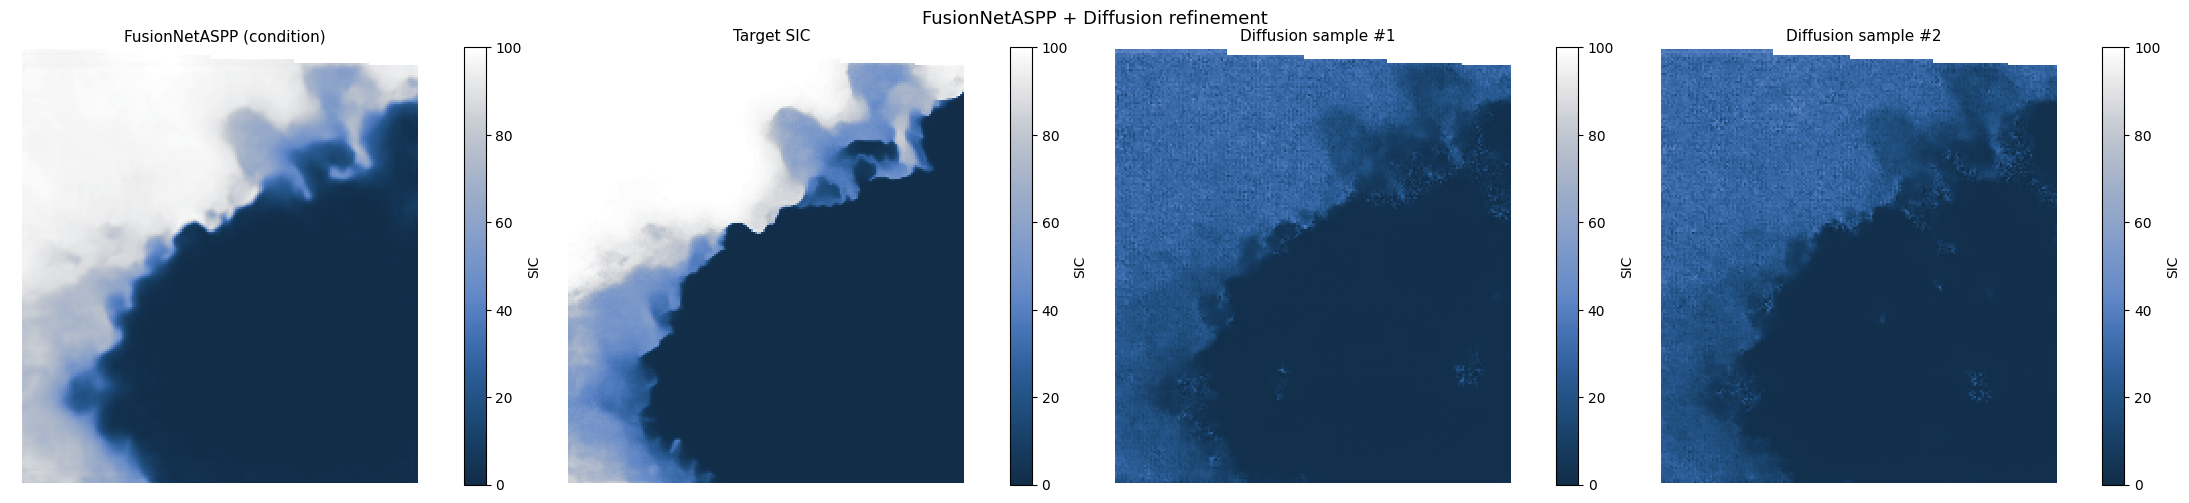

In [35]:
score_model = torch.nn.DataParallel(ScoreNet(marginal_prob_std=marginal_prob_std_fn))
score_model = score_model.to(device)
score_model.load_state_dict(torch.load(DIFF_CKPT, map_location=device))
score_model.eval()

# Get a validation batch
amsr2, sic, mask = next(itertools.islice(val_dataloader, 1, None))
amsr2 = amsr2.to(device)
sic   = sic.to(device)
mask  = mask.to(device)

x = sic
target_size = (x.shape[-2], x.shape[-1])

with torch.no_grad():
    y = fusion_model(amsr2, target_size=target_size)  # (B, 1, H, W)

sampler  = Euler_Maruyama_sampler
x_estim  = sampler(score_model, marginal_prob_std_fn, diffusion_coeff_fn,
                   y.nan_to_num(), batch_size=x.shape[0], num_steps=500, device=device)
x_estim2 = sampler(score_model, marginal_prob_std_fn, diffusion_coeff_fn,
                   y.nan_to_num(), batch_size=x.shape[0], num_steps=500, device=device)

# ── Plot ──────────────────────────────────────────────────────────────────────
idx      = 2
mask_np  = mask[idx, 0].cpu().numpy().astype(bool)
sic_np   = np.where(mask_np, np.nan, sic[idx, 0].cpu().numpy())
y_np     = np.where(mask_np, np.nan, y[idx, 0].detach().cpu().numpy())
y_np     = np.clip(y_np, 0, 100)  # clip condition to [0, 100] for better visualization
est1_np  = np.where(mask_np, np.nan, x_estim[idx, 0].detach().cpu().numpy())
est2_np  = np.where(mask_np, np.nan, x_estim2[idx, 0].detach().cpu().numpy())
est1_np = np.clip(est1_np, 0, 100)
est2_np = np.clip(est2_np, 0, 100)

cmap = sic_trunc  # reuse colormap from cell 19
vmin, vmax = 0, 100

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
titles = ['FusionNetASPP (condition)', 'Target SIC', 'Diffusion sample #1', 'Diffusion sample #2']
arrays = [y_np, sic_np, est1_np, est2_np]

for ax, arr, title in zip(axes, arrays, titles):
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, label='SIC')

plt.suptitle('FusionNetASPP + Diffusion refinement', fontsize=13)
plt.tight_layout()
plt.show()

In [42]:
diff_ckpt = torch.load(DIFF_CKPT, map_location='cpu', weights_only=True)
for k, v in diff_ckpt.items():
    print(f"{k:50s}  {str(v.shape):30s}  {v.dtype}")

n_params = sum(v.numel() for v in diff_ckpt.values())
print(f"Keys: {len(diff_ckpt)}")
print(f"Total parameters: {n_params:,}")
print(f"First 5 keys: {list(diff_ckpt.keys())[:5]}")

module.embed.0.W                                    torch.Size([128])               torch.float32
module.embed.1.weight                               torch.Size([256, 256])          torch.float32
module.embed.1.bias                                 torch.Size([256])               torch.float32
module.conv1.weight                                 torch.Size([32, 2, 3, 3])       torch.float32
module.conv2.weight                                 torch.Size([64, 32, 3, 3])      torch.float32
module.conv3.weight                                 torch.Size([128, 64, 3, 3])     torch.float32
module.conv4.weight                                 torch.Size([256, 128, 3, 3])    torch.float32
module.dense1.dense.weight                          torch.Size([32, 256])           torch.float32
module.dense1.dense.bias                            torch.Size([32])                torch.float32
module.dense2.dense.weight                          torch.Size([64, 256])           torch.float32
module.dense2.dense.